# Q3 — Hyperparameters and Hyperparameter Tuning
### Comparing Logistic Regression, Naive Bayes, Linear SVM, and Random Forest

This notebook answers the two Q3 tasks for the group's four models, all built
on the same IMDB sentiment dataset from Q1 (`imdb_cleaned.csv`):

| Model | Group member's notebook |
|---|---|
| Logistic Regression | Logistic Regression notebook |
| Multinomial Naive Bayes | `Q2_Supervised_Text_Classification.ipynb` |
| Linear SVM | `Q2_Supervised_Text_Classification.ipynb` |
| Random Forest | `random_forest.ipynb` |

**Why a shared setup is used here:** each teammate's own notebook used slightly
different TF-IDF settings and, in places, different duplicate-handling. For the
hyperparameter comparison to be fair, all four models below are trained on
**one shared train/test split and one shared TF-IDF feature matrix**, using
the same `random_state=42`. Individual notebooks remain the source of truth for
each member's own Q2 build; this notebook exists specifically to answer Q3
in a way the whole group can present together.

1. **Task 1:** list and explain the hyperparameters of every model.
2. **Task 2:** tune each model with grid search or randomized search, and
   report the selected hyperparameters together with the results.


## 1. Imports

In [1]:
# Core libraries
import time
import json
from pathlib import Path
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting and hyperparameter search
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
)

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# The four models being compared
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

sns.set_style("whitegrid")
RANDOM_STATE = 42   # fixed seed used everywhere below for reproducibility


## 2. Load Data and Create a Shared Train/Test Split

The same cleaned dataset from Q1 is used for every model. Exact duplicate
reviews are removed before splitting — otherwise the same review text could
appear in both the training and test sets, which would leak information and
inflate test performance.

In [2]:
# Locate the cleaned dataset whether Jupyter starts here or at the TSXA project root.
candidate_data_paths = [
    Path("imdb_cleaned.csv"),
    Path("../txsa_p2/txsa_p2/imdb_cleaned.csv"),
    Path("txsa_p2/txsa_p2/imdb_cleaned.csv"),
]
data_path = next((path.resolve() for path in candidate_data_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not locate imdb_cleaned.csv.")

candidate_artifact_dirs = [
    Path.cwd(),
    Path.cwd() / "Part_B_Q4_Evaluation",
    Path.cwd() / "source" / "TSXA" / "Part_B_Q4_Evaluation",
    Path.cwd() / "TSXA" / "Part_B_Q4_Evaluation",
]
ARTIFACT_DIR = next(
    (folder.resolve() for folder in candidate_artifact_dirs if (folder / "PartB_Q3.ipynb").exists()),
    Path.cwd().resolve(),
)

df = pd.read_csv(data_path)
df = df.dropna(subset=["final_review", "label"])

# Remove exact duplicate reviews to avoid train/test leakage
rows_before = len(df)
df = df.drop_duplicates(subset="final_review").reset_index(drop=True)
print(f"Removed {rows_before - len(df)} duplicate reviews")
print(f"Final dataset shape: {df.shape}")

# One shared split for all four models
X_train, X_test, y_train, y_test = train_test_split(
    df["final_review"], df["label"],
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df["label"]   # preserve the ~50/50 class balance
)

print(f"Training reviews: {len(X_train):,}")
print(f"Test reviews:     {len(X_test):,}")


Removed 423 duplicate reviews
Final dataset shape: (49577, 6)
Training reviews: 39,661
Test reviews:     9,916


## 3. Shared TF-IDF Feature Extraction

All four models are trained on the **same** TF-IDF feature matrix so that
differences in results reflect the models and their hyperparameters, not
differences in the input features.

- `ngram_range=(1, 2)`: unigrams and bigrams (captures short phrases like "not good")
- `min_df=5`: drop terms appearing in fewer than 5 reviews (removes noise/typos)
- `max_df=0.9`: drop terms appearing in over 90% of reviews (too generic to be useful)
- `max_features=10000`: caps the vocabulary size for tractable training/tuning time
- `sublinear_tf=True`: applies `1 + log(tf)` scaling, softening the effect of very frequent terms

The vectoriser is fit on the training data only, then used to transform the
test data, avoiding any leakage from the test set into the vocabulary.

In [3]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9,
    max_features=10000,
    sublinear_tf=True
)

t0 = time.time()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print(f"TF-IDF vectorisation completed in {time.time() - t0:.1f}s")
print(f"Training feature matrix: {X_train_tfidf.shape}")
print(f"Test feature matrix:     {X_test_tfidf.shape}")


TF-IDF vectorisation completed in 19.1s
Training feature matrix: (39661, 10000)
Test feature matrix:     (9916, 10000)


## 4. Task 1 — Hyperparameters of Each Model

The table below lists the main tunable hyperparameters for each of the four
models, what each one controls, and the trade-off it represents.

In [4]:
hyperparameter_table = pd.DataFrame([
    # --- Logistic Regression ---
    {"Model": "Logistic Regression", "Hyperparameter": "C",
     "Purpose": "Inverse of regularisation strength.",
     "Effect / trade-off": "Smaller C = stronger regularisation (simpler decision boundary, less overfitting); larger C fits the training data more closely and risks overfitting."},
    {"Model": "Logistic Regression", "Hyperparameter": "penalty",
     "Purpose": "Type of regularisation term added to the loss function.",
     "Effect / trade-off": "'l2' shrinks all coefficients smoothly; 'l1' can shrink some coefficients to exactly zero, giving automatic feature selection."},
    {"Model": "Logistic Regression", "Hyperparameter": "solver",
     "Purpose": "Optimisation algorithm used to fit the coefficients.",
     "Effect / trade-off": "Different solvers support different penalties and scale differently with dataset size; e.g. 'liblinear' suits smaller/sparse data, 'lbfgs' suits l2 only."},
    {"Model": "Logistic Regression", "Hyperparameter": "max_iter",
     "Purpose": "Maximum number of iterations for the solver to converge.",
     "Effect / trade-off": "Too low can stop training before convergence (misleading coefficients); higher values cost more training time."},

    # --- Naive Bayes ---
    {"Model": "Multinomial Naive Bayes", "Hyperparameter": "alpha",
     "Purpose": "Laplace/Lidstone additive smoothing applied to word counts.",
     "Effect / trade-off": "Prevents zero probabilities for unseen words. Small alpha follows the training data closely (risk of overfitting to rare words); large alpha smooths predictions toward the overall class distribution (risk of underfitting)."},
    {"Model": "Multinomial Naive Bayes", "Hyperparameter": "fit_prior",
     "Purpose": "Whether to learn class prior probabilities from the training data.",
     "Effect / trade-off": "If False, a uniform class prior is assumed instead, which matters more when classes are imbalanced."},

    # --- Linear SVM ---
    {"Model": "Linear SVM", "Hyperparameter": "C",
     "Purpose": "Penalty for margin violations (misclassified/close points).",
     "Effect / trade-off": "Small C allows a wider margin with more tolerated violations (more regularisation); large C forces a narrower margin that fits training points more exactly (risk of overfitting)."},
    {"Model": "Linear SVM", "Hyperparameter": "loss",
     "Purpose": "Loss function used to penalise margin violations.",
     "Effect / trade-off": "'hinge' is the standard SVM loss; 'squared_hinge' penalises larger violations more heavily and is the scikit-learn default."},
    {"Model": "Linear SVM", "Hyperparameter": "max_iter",
     "Purpose": "Maximum optimisation iterations.",
     "Effect / trade-off": "Same trade-off as Logistic Regression: too low risks non-convergence, especially for very small C."},

    # --- Random Forest ---
    {"Model": "Random Forest", "Hyperparameter": "n_estimators",
     "Purpose": "Number of decision trees in the forest.",
     "Effect / trade-off": "More trees generally stabilise and improve predictions but increase training time and memory linearly."},
    {"Model": "Random Forest", "Hyperparameter": "max_depth",
     "Purpose": "Maximum depth of each decision tree.",
     "Effect / trade-off": "Shallower trees reduce overfitting but may underfit; unlimited depth ('None') can memorise training noise."},
    {"Model": "Random Forest", "Hyperparameter": "min_samples_split",
     "Purpose": "Minimum samples required to split an internal node.",
     "Effect / trade-off": "Larger values produce simpler, more regularised trees."},
    {"Model": "Random Forest", "Hyperparameter": "min_samples_leaf",
     "Purpose": "Minimum samples that must remain in a leaf node.",
     "Effect / trade-off": "Larger leaves smooth out noisy, overly specific rules but can blur genuine minority patterns."},
    {"Model": "Random Forest", "Hyperparameter": "max_features",
     "Purpose": "Number of features considered when looking for the best split.",
     "Effect / trade-off": "Fewer features per split (e.g. 'sqrt') increases tree diversity and reduces correlation between trees, generally improving the ensemble."},
    {"Model": "Random Forest", "Hyperparameter": "criterion",
     "Purpose": "Function used to measure split quality ('gini' or 'entropy').",
     "Effect / trade-off": "Usually produces similar trees; entropy is slightly more computationally expensive."},
    {"Model": "Random Forest", "Hyperparameter": "bootstrap",
     "Purpose": "Whether each tree is trained on a bootstrap-resampled subset of the data.",
     "Effect / trade-off": "True (default) introduces the randomness that makes an ensemble of trees diverse; False uses the whole dataset for every tree, reducing diversity."},
])

pd.set_option("display.max_colwidth", 120)
hyperparameter_table


,Model,Hyperparameter,Purpose,Effect / trade-off
0,Logistic Regression,C,Inverse of regularisation strength.,"Smaller C = stronger regularisation (simpler decision boundary, less overfitting); larger C fits the training data m..."
1,Logistic Regression,penalty,Type of regularisation term added to the loss function.,"'l2' shrinks all coefficients smoothly; 'l1' can shrink some coefficients to exactly zero, giving automatic feature ..."
2,Logistic Regression,solver,Optimisation algorithm used to fit the coefficients.,Different solvers support different penalties and scale differently with dataset size; e.g. 'liblinear' suits smalle...
3,Logistic Regression,max_iter,Maximum number of iterations for the solver to converge.,Too low can stop training before convergence (misleading coefficients); higher values cost more training time.
4,Multinomial Naive Bayes,alpha,Laplace/Lidstone additive smoothing applied to word counts.,Prevents zero probabilities for unseen words. Small alpha follows the training data closely (risk of overfitting to ...
5,Multinomial Naive Bayes,fit_prior,Whether to learn class prior probabilities from the training data.,"If False, a uniform class prior is assumed instead, which matters more when classes are imbalanced."
6,Linear SVM,C,Penalty for margin violations (misclassified/close points).,Small C allows a wider margin with more tolerated violations (more regularisation); large C forces a narrower margin...
7,Linear SVM,loss,Loss function used to penalise margin violations.,'hinge' is the standard SVM loss; 'squared_hinge' penalises larger violations more heavily and is the scikit-learn d...
8,Linear SVM,max_iter,Maximum optimisation iterations.,"Same trade-off as Logistic Regression: too low risks non-convergence, especially for very small C."
9,Random Forest,n_estimators,Number of decision trees in the forest.,More trees generally stabilise and improve predictions but increase training time and memory linearly.


## 5. Task 2 — Hyperparameter Search Setup

All four searches optimise **F1-score**, since the classes are balanced but
F1 still rewards a model that balances precision and recall rather than
favouring one at the other's expense.

- Logistic Regression, Naive Bayes, and Linear SVM use **GridSearchCV** with
  5-fold stratified cross-validation on the **full** training set — these
  models are fast enough to train many times.
- Random Forest uses **RandomizedSearchCV** on a smaller stratified subsample
  of the training data with 3-fold cross-validation, because each Random
  Forest fit is far more computationally expensive and the hyperparameter
  space is much larger. This mirrors the approach used in the group's Random
  Forest notebook.

In [5]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

search_results = {}   # collects best params / best CV score / search time for every model


### 5.1 Logistic Regression — Grid Search

In [6]:
lr_param_grid = {"C": [0.01, 0.1, 1, 10, 100]}

t0 = time.time()
lr_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    param_grid=lr_param_grid,
    scoring="f1",
    cv=cv5,
    n_jobs=1
)
lr_search.fit(X_train_tfidf, y_train)
lr_search_time = time.time() - t0

print(f"Search time: {lr_search_time:.1f}s")
print(f"Best hyperparameters: {lr_search.best_params_}")
print(f"Best cross-validated F1: {lr_search.best_score_:.4f}")

search_results["Logistic Regression"] = {
    "best_params": lr_search.best_params_,
    "best_cv_f1": lr_search.best_score_,
    "search_time_s": lr_search_time,
}

# Full grid results, sorted by rank
pd.DataFrame(lr_search.cv_results_)[
    ["param_C", "mean_test_score", "std_test_score", "rank_test_score"]
].sort_values("rank_test_score")


Search time: 8.9s
Best hyperparameters: {'C': 1}
Best cross-validated F1: 0.8939


,param_C,mean_test_score,std_test_score,rank_test_score
2,1.00,0.893950,0.002082,1
3,10.00,0.887749,0.002440,2
1,0.10,0.876885,0.000582,3
4,100.00,0.871304,0.002751,4
0,0.01,0.852017,0.001703,5


### 5.2 Multinomial Naive Bayes — Grid Search

In [7]:
nb_param_grid = {"alpha": [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]}

t0 = time.time()
nb_search = GridSearchCV(
    estimator=MultinomialNB(),
    param_grid=nb_param_grid,
    scoring="f1",
    cv=cv5,
    n_jobs=1
)
nb_search.fit(X_train_tfidf, y_train)
nb_search_time = time.time() - t0

print(f"Search time: {nb_search_time:.1f}s")
print(f"Best hyperparameters: {nb_search.best_params_}")
print(f"Best cross-validated F1: {nb_search.best_score_:.4f}")

search_results["Naive Bayes"] = {
    "best_params": nb_search.best_params_,
    "best_cv_f1": nb_search.best_score_,
    "search_time_s": nb_search_time,
}

pd.DataFrame(nb_search.cv_results_)[
    ["param_alpha", "mean_test_score", "std_test_score", "rank_test_score"]
].sort_values("rank_test_score")


Search time: 1.0s
Best hyperparameters: {'alpha': 1.0}
Best cross-validated F1: 0.8696


,param_alpha,mean_test_score,std_test_score,rank_test_score
3,1.00,0.869583,0.002254,1
4,2.00,0.869531,0.002551,2
2,0.50,0.869387,0.002290,3
1,0.10,0.869075,0.002103,4
5,5.00,0.869066,0.002362,5
0,0.01,0.868792,0.001870,6


### 5.3 Linear SVM — Grid Search

In [8]:
svm_param_grid = {"C": [0.001, 0.01, 0.1, 1, 10]}

t0 = time.time()
svm_search = GridSearchCV(
    estimator=LinearSVC(max_iter=5000, random_state=RANDOM_STATE),
    param_grid=svm_param_grid,
    scoring="f1",
    cv=cv5,
    n_jobs=1
)
svm_search.fit(X_train_tfidf, y_train)
svm_search_time = time.time() - t0

print(f"Search time: {svm_search_time:.1f}s")
print(f"Best hyperparameters: {svm_search.best_params_}")
print(f"Best cross-validated F1: {svm_search.best_score_:.4f}")

search_results["Linear SVM"] = {
    "best_params": svm_search.best_params_,
    "best_cv_f1": svm_search.best_score_,
    "search_time_s": svm_search_time,
}

pd.DataFrame(svm_search.cv_results_)[
    ["param_C", "mean_test_score", "std_test_score", "rank_test_score"]
].sort_values("rank_test_score")


Search time: 13.3s
Best hyperparameters: {'C': 0.1}
Best cross-validated F1: 0.8947


,param_C,mean_test_score,std_test_score,rank_test_score
2,0.100,0.894750,0.001931,1
3,1.000,0.884162,0.001861,2
1,0.010,0.876280,0.000488,3
4,10.000,0.857303,0.002950,4
0,0.001,0.850768,0.001934,5


### 5.4 Random Forest — Randomized Search

A 8,000-review stratified subsample of the training set is used for tuning
(rather than all ~40,000), and only 6 randomly sampled hyperparameter
combinations are evaluated with 3-fold CV. This keeps the search
computationally practical while still exploring a wide hyperparameter space.
The winning configuration is refit on the **full** training set in Section 6.

In [9]:
TUNING_SAMPLE_SIZE = 8000

if X_train_tfidf.shape[0] > TUNING_SAMPLE_SIZE:
    X_tune, _, y_tune, _ = train_test_split(
        X_train_tfidf, y_train,
        train_size=TUNING_SAMPLE_SIZE,
        random_state=RANDOM_STATE,
        stratify=y_train
    )
else:
    X_tune, y_tune = X_train_tfidf, y_train

rf_param_distributions = {
    "n_estimators": [100, 200, 300],
    "criterion": ["gini", "entropy"],
    "max_depth": [20, 40, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False],
}

t0 = time.time()
rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
    param_distributions=rf_param_distributions,
    n_iter=6,
    scoring="f1",
    cv=cv3,
    n_jobs=1,
    random_state=RANDOM_STATE,
    verbose=1
)
rf_search.fit(X_tune, y_tune)
rf_search_time = time.time() - t0

print(f"Search time: {rf_search_time:.1f}s")
print(f"Best hyperparameters: {rf_search.best_params_}")
print(f"Best cross-validated F1: {rf_search.best_score_:.4f}")

search_results["Random Forest"] = {
    "best_params": rf_search.best_params_,
    "best_cv_f1": rf_search.best_score_,
    "search_time_s": rf_search_time,
}

pd.DataFrame(rf_search.cv_results_)[
    ["params", "mean_test_score", "std_test_score", "rank_test_score"]
].sort_values("rank_test_score")


Fitting 3 folds for each of 6 candidates, totalling 18 fits


Search time: 70.0s
Best hyperparameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 40, 'criterion': 'gini', 'bootstrap': True}
Best cross-validated F1: 0.8499


,params,mean_test_score,std_test_score,rank_test_score
3,"{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 40, 'crit...",0.849899,0.005750,1
4,"{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 40, 'crit...",0.842073,0.005504,2
0,"{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 40, 'crite...",0.841029,0.001805,3
1,"{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'cri...",0.839760,0.008623,4
5,"{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 20, 'crite...",0.836936,0.004859,5
2,"{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'cri...",0.833817,0.007184,6


## 6. Refit Each Tuned Model and Evaluate on the Held-Out Test Set

Every model is now refit with its best hyperparameters on the **full**
training set, then evaluated once on the same untouched test set — so the
final comparison is on equal footing.

In [10]:
def evaluate_on_test(model, name):
    """Fit on the full training set, predict on the test set, and return metrics."""
    t0 = time.time()
    model.fit(X_train_tfidf, y_train)
    fit_time = time.time() - t0

    y_pred = model.predict(X_test_tfidf)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_tfidf)[:, 1]
    else:
        y_score = model.decision_function(X_test_tfidf)

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_score),
        "Best CV F1": search_results[name]["best_cv_f1"],
        "Fit time (s)": fit_time,
    }
    return model, y_pred, y_score, metrics


final_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, **lr_search.best_params_),
    "Naive Bayes": MultinomialNB(**nb_search.best_params_),
    "Linear SVM": LinearSVC(max_iter=5000, random_state=RANDOM_STATE, **svm_search.best_params_),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1, **rf_search.best_params_),
}

fitted_models, predictions, scores, all_metrics = {}, {}, {}, []
for name, model in final_models.items():
    fitted_model, y_pred, y_score, metrics = evaluate_on_test(model, name)
    fitted_models[name] = fitted_model
    predictions[name] = y_pred
    scores[name] = y_score
    all_metrics.append(metrics)
    print(f"{name}: done")

comparison_df = pd.DataFrame(all_metrics).set_index("Model")

# Export prediction-level evidence so Q4 can calculate its own metrics without rerunning tuning.
model_prefixes = {
    "Logistic Regression": "logistic_regression",
    "Naive Bayes": "naive_bayes",
    "Linear SVM": "linear_svm",
    "Random Forest": "random_forest",
}
prediction_export = pd.DataFrame({"y_true": np.asarray(y_test, dtype=int)})
for name, prefix in model_prefixes.items():
    prediction_export[f"{prefix}_pred"] = np.asarray(predictions[name], dtype=int)
    prediction_export[f"{prefix}_score"] = np.asarray(scores[name], dtype=float)

prediction_path = ARTIFACT_DIR / "q3_test_predictions.csv"
metadata_path = ARTIFACT_DIR / "q3_model_metadata.csv"
prediction_export.to_csv(prediction_path, index=False)
comparison_df[["Best CV F1", "Fit time (s)"]].reset_index().to_csv(metadata_path, index=False)

print(f"Saved {len(prediction_export):,} test predictions to: {prediction_path.name}")
print(f"Saved model metadata to: {metadata_path.name}")
comparison_df.round(4)


Logistic Regression: done
Naive Bayes: done


Linear SVM: done


Random Forest: done
Saved 9,916 test predictions to: q3_test_predictions.csv
Saved model metadata to: q3_model_metadata.csv


,Accuracy,Precision,Recall,F1-score,ROC-AUC,Best CV F1,Fit time (s)
Model,,,,,,,
Logistic Regression,0.8904,0.8829,0.9011,0.8919,0.9605,0.8939,0.3457
Naive Bayes,0.8632,0.8539,0.8774,0.8655,0.9378,0.8696,0.0161
Linear SVM,0.8923,0.8844,0.9036,0.8939,0.9612,0.8947,0.5662
Random Forest,0.8529,0.8210,0.9040,0.8605,0.9350,0.8499,4.8571


### Best Hyperparameters — Summary Table

In [11]:
best_params_table = pd.DataFrame([
    {"Model": name, **{f"param: {k}": v for k, v in res["best_params"].items()},
     "Best CV F1": round(res["best_cv_f1"], 4),
     "Search time (s)": round(res["search_time_s"], 1)}
    for name, res in search_results.items()
])
best_params_table


,Model,param: C,Best CV F1,Search time (s),param: alpha,param: n_estimators,param: min_samples_split,param: min_samples_leaf,param: max_features,param: max_depth,param: criterion,param: bootstrap
0,Logistic Regression,1.0,0.8939,8.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Naive Bayes,NaN,0.8696,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Linear SVM,0.1,0.8947,13.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Random Forest,NaN,0.8499,70.0,NaN,200.0,10.0,4.0,log2,40.0,gini,True


### Performance Comparison Chart

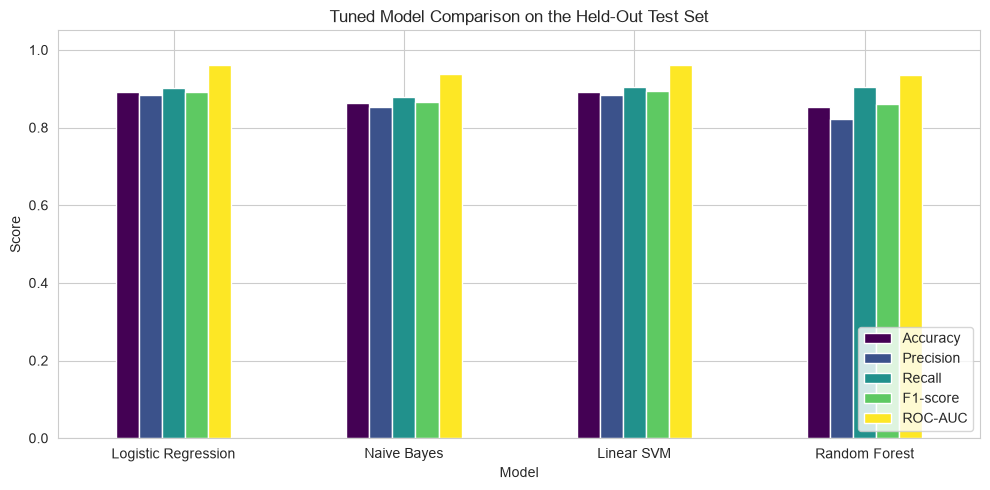

In [12]:
comparison_df[["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]].plot(
    kind="bar", figsize=(10, 5), rot=0, colormap="viridis"
)
plt.title("Tuned Model Comparison on the Held-Out Test Set")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


### Confusion Matrices

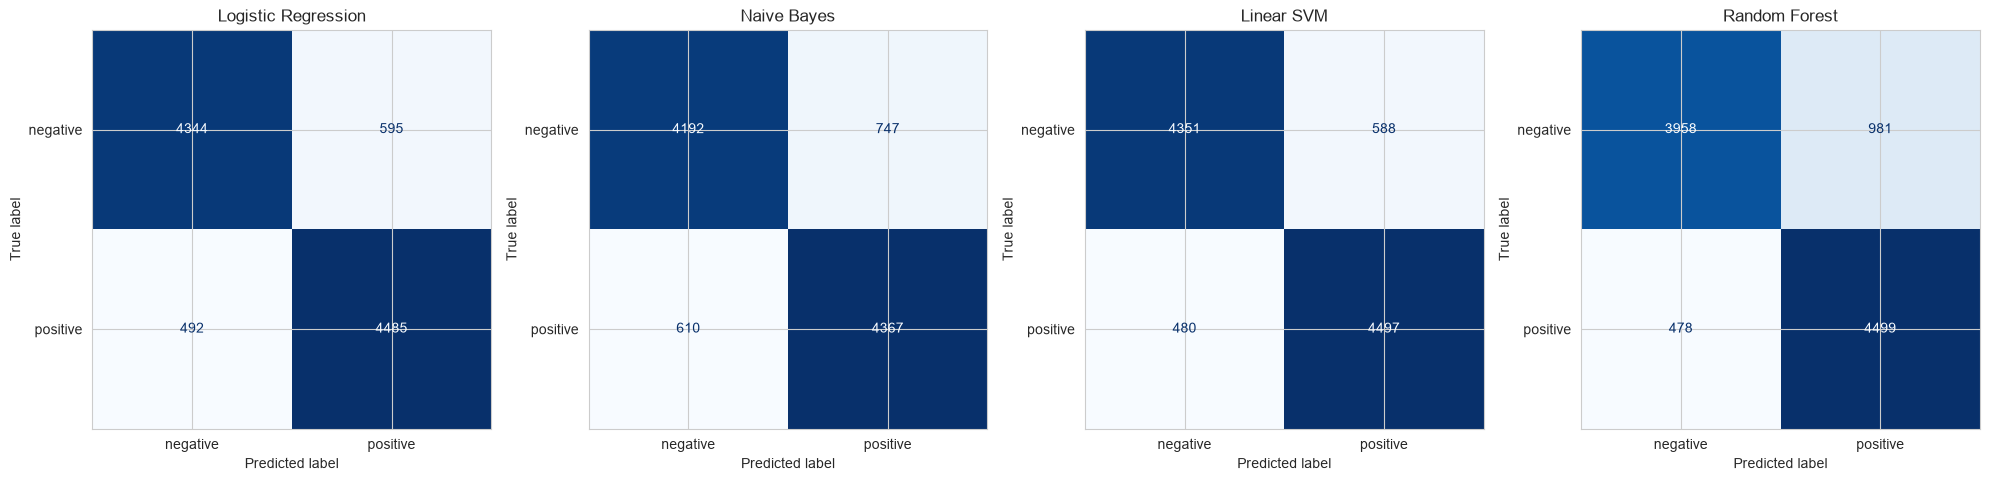

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, name in zip(axes, final_models.keys()):
    cm = confusion_matrix(y_test, predictions[name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["negative", "positive"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()


### ROC Curve Comparison

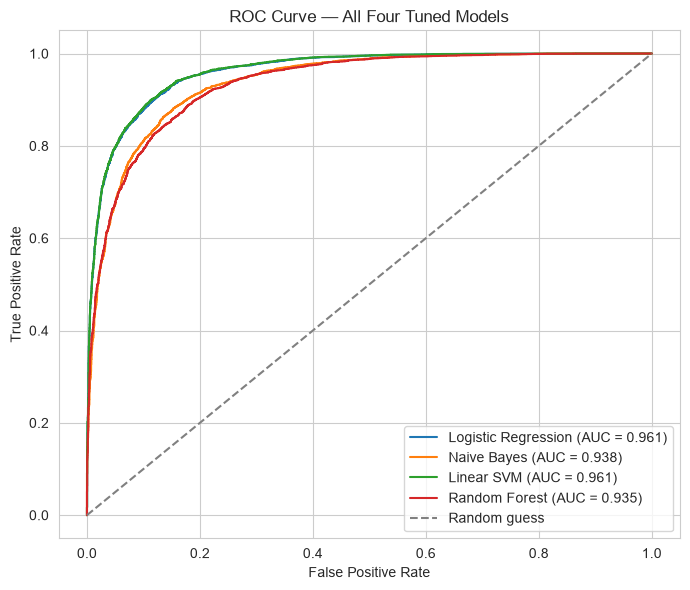

In [14]:
plt.figure(figsize=(7, 6))

for name in final_models.keys():
    fpr, tpr, _ = roc_curve(y_test, scores[name])
    auc = comparison_df.loc[name, "ROC-AUC"]
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — All Four Tuned Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()
